# Experimentos y Visualizaciones — DQN vs Minimax en Damas

Este notebook carga los resultados generados por los scripts del proyecto y reproduce todas las figuras del informe. Corre de principio a fin sde manera automatizada siempre que los archivos en results/ existan (se generan con los scripts indicados en cada
sección).

Secciones:
1. Curva de aprendizaje del DQN (self-play)
2. Barrido de hiperparametros y comparacion arquitectonica
3. Torneo DQN vs Minimax a distintas profundidades
4. Torneo final y clasificacion ELO
5. Ejemplo cualitativo: partida comentada

In [1]:
import os, sys
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

matplotlib.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(ROOT, 'src'))

RESULTS   = os.path.join(ROOT, 'results')
FIG_DIR   = os.path.join(ROOT, 'Informe', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, bbox_inches='tight')
    print(f'Figura guardada: {path}')

print('Entorno listo. ROOT =', ROOT)

Entorno listo. ROOT = c:\Users\walte\Desktop\ia\proyectoDamasDQN\damas-dqn-minimax


---
## 1. Curva de aprendizaje del DQN

Requiere haber ejecutado el entrenamiento con la opcion --log-csv:

```bash
python src/selfplay.py --episodes 1000 --log-csv results/training_log.csv
```

Si el archivo no existe, la celda lo indica y se puede omitir esta seccion.

Figura guardada: c:\Users\walte\Desktop\ia\proyectoDamasDQN\damas-dqn-minimax\Informe\figures\curva_aprendizaje.png


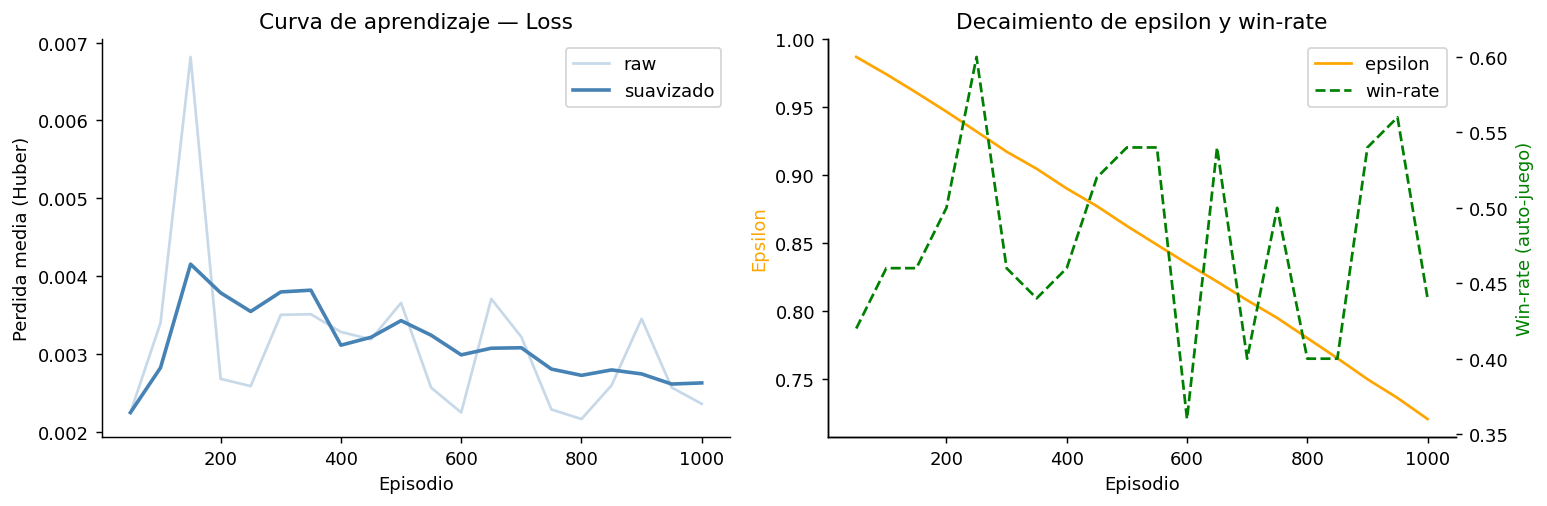

    episode  avg_loss  epsilon  win_rate  learn_steps
15      800  0.002165   0.7802      0.40        11570
16      850  0.002597   0.7654      0.40        12349
17      900  0.003452   0.7500      0.54        13158
18      950  0.002570   0.7362      0.56        13884
19     1000  0.002360   0.7207      0.44        14701


In [5]:
log_path = os.path.join(RESULTS, 'training_log.csv')

if not os.path.exists(log_path):
    print('Archivo no encontrado:', log_path)
    print('Ejecuta: python src/selfplay.py --episodes 1000 --log-csv results/training_log.csv')
else:
    df_log = pd.read_csv(log_path)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Perdida suavizada
    ax = axes[0]
    smooth = df_log['avg_loss'].rolling(5, min_periods=1).mean()
    ax.plot(df_log['episode'], df_log['avg_loss'], alpha=0.3, color='steelblue', label='raw')
    ax.plot(df_log['episode'], smooth, color='steelblue', linewidth=2, label='suavizado')
    ax.set_xlabel('Episodio')
    ax.set_ylabel('Perdida media (Huber)')
    ax.set_title('Curva de aprendizaje — Loss')
    ax.legend()

    # Epsilon y win-rate
    ax2 = axes[1]
    ax2.plot(df_log['episode'], df_log['epsilon'], color='orange', label='epsilon')
    ax2b = ax2.twinx()
    ax2b.plot(df_log['episode'], df_log['win_rate'], color='green', linestyle='--', label='win-rate')
    ax2.set_xlabel('Episodio')
    ax2.set_ylabel('Epsilon', color='orange')
    ax2b.set_ylabel('Win-rate (auto-juego)', color='green')
    ax2.set_title('Decaimiento de epsilon y win-rate')
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2b.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2)

    plt.tight_layout()
    savefig('curva_aprendizaje.png')
    plt.show()
    print(df_log.tail())

---
## 2. Barrido de hiperparametros y comparacion arquitectonica

Requiere haber ejecutado:

```bash
python src/tuning/run.py --steps 3000 --out results/tuning.csv
```

Columnas disponibles: ['group', 'name', 'lr', 'gamma', 'buffer', 'target_div', 'hidden', 'win_rate', 'avg_loss', 'learn_steps']


,group,name,lr,gamma,buffer,target_div,hidden,win_rate,avg_loss,learn_steps
0,hparams,baseline,0.0010,0.99,5000,10,512x512,0.40,0.002747,2969
1,hparams,lr=5e-4,0.0005,0.99,5000,10,512x512,0.20,0.001934,2969
2,hparams,lr=1e-4,0.0001,0.99,5000,10,512x512,0.15,0.002762,2969
3,hparams,gamma=0.95,0.0010,0.95,5000,10,512x512,0.45,0.002384,2969
4,hparams,gamma=0.90,0.0010,0.90,5000,10,512x512,0.50,0.002005,2969
5,hparams,buffer=20k,0.0010,0.99,20000,10,512x512,0.40,0.002173,2969
6,hparams,target=rápido,0.0010,0.99,5000,40,512x512,0.45,0.003381,2969
7,hparams,target=lento,0.0010,0.99,5000,4,512x512,0.30,0.002479,2969
8,arch,mlp-256x2,0.0010,0.99,5000,10,256x256,0.25,0.002292,2969
9,arch,mlp-512x2,0.0010,0.99,5000,10,512x512,0.60,0.002377,2969


Figura guardada: c:\Users\walte\Desktop\ia\proyectoDamasDQN\damas-dqn-minimax\Informe\figures\tuning_winrate.png


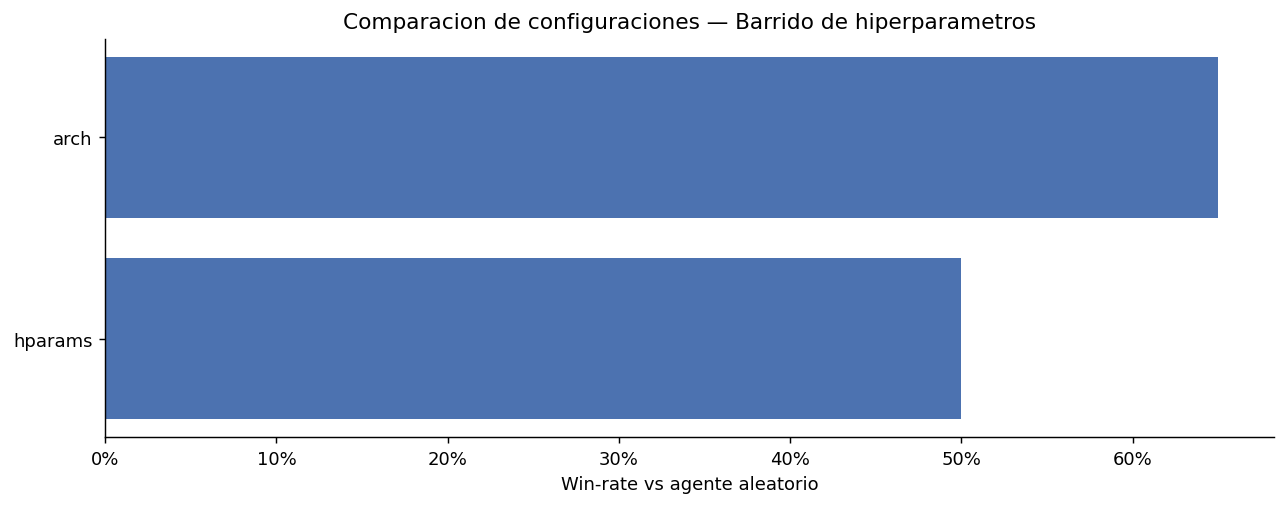

In [6]:
tuning_path = os.path.join(RESULTS, 'tuning.csv')

if not os.path.exists(tuning_path):
    print('Archivo no encontrado:', tuning_path)
    print('Ejecuta: python src/tuning/run.py --steps 3000 --out results/tuning.csv')
else:
    df_tune = pd.read_csv(tuning_path)
    print('Columnas disponibles:', df_tune.columns.tolist())
    display(df_tune)

    # Win-rate por configuracion
    fig, ax = plt.subplots(figsize=(10, 4))
    colors  = ['#4C72B0' if 'hparam' in str(row.get('study','')) else '#DD8452'
               for _, row in df_tune.iterrows()]
    bars = ax.barh(df_tune.iloc[:, 0], df_tune['win_rate'], color='#4C72B0')
    ax.set_xlabel('Win-rate vs agente aleatorio')
    ax.set_title('Comparacion de configuraciones — Barrido de hiperparametros')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.tight_layout()
    savefig('tuning_winrate.png')
    plt.show()

---
## 3. Torneo DQN vs Minimax a distintas profundidades

Generado por `src/eval/run.py`. Archivo: `results/eval_depth.csv`.

,dqn_label,depth,dqn_wins,mm_wins,draws,total,win_rate
0,DQN(ep14480),3,0,20,0,20,0.0
1,DQN(ep14480),4,10,10,0,20,0.5
2,DQN(ep14480),5,0,20,0,20,0.0
3,DQN(ep14480),6,0,20,0,20,0.0


Figura guardada: c:\Users\walte\Desktop\ia\proyectoDamasDQN\damas-dqn-minimax\Informe\figures\torneo_profundidades.png


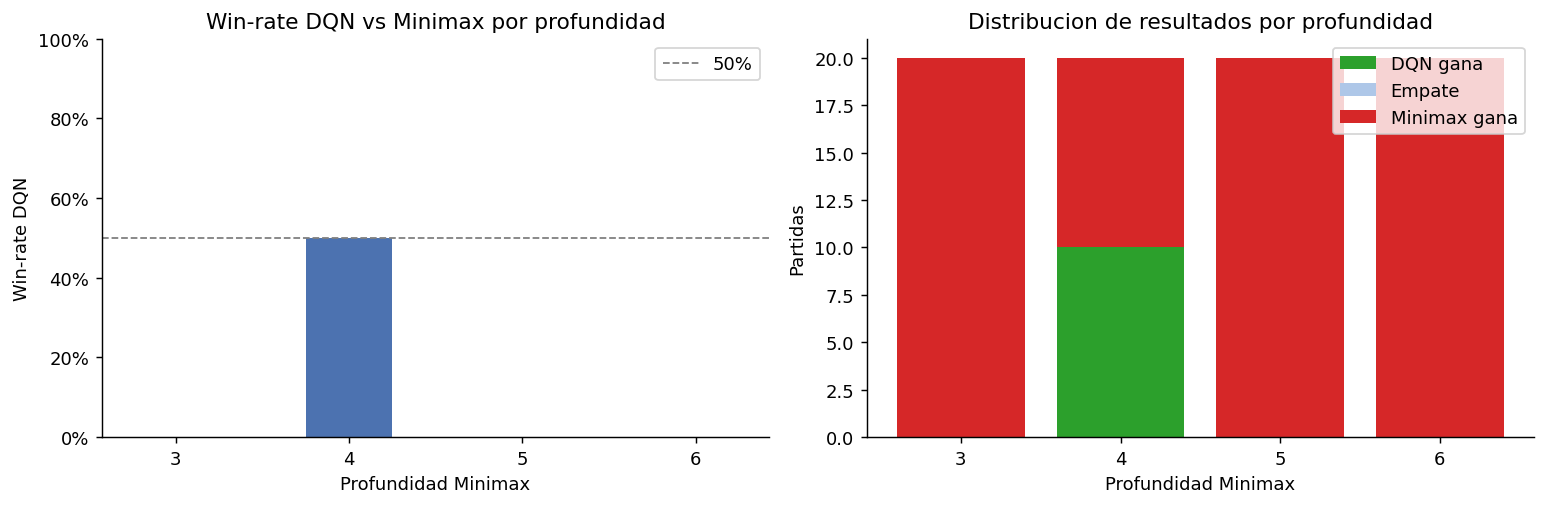

In [7]:
depth_path = os.path.join(RESULTS, 'eval_depth.csv')
df_depth   = pd.read_csv(depth_path)
display(df_depth)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Win-rate por profundidad
ax = axes[0]
ax.bar(df_depth['depth'].astype(str), df_depth['win_rate'],
       color='#4C72B0', width=0.5)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='50%')
ax.set_xlabel('Profundidad Minimax')
ax.set_ylabel('Win-rate DQN')
ax.set_title('Win-rate DQN vs Minimax por profundidad')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1)
ax.legend()

# Distribucion de resultados (stacked bar)
ax = axes[1]
depths = df_depth['depth'].astype(str)
ax.bar(depths, df_depth['dqn_wins'],  label='DQN gana',  color='#2ca02c')
ax.bar(depths, df_depth['draws'],     label='Empate',    color='#aec7e8',
       bottom=df_depth['dqn_wins'])
ax.bar(depths, df_depth['mm_wins'],   label='Minimax gana', color='#d62728',
       bottom=df_depth['dqn_wins'] + df_depth['draws'])
ax.set_xlabel('Profundidad Minimax')
ax.set_ylabel('Partidas')
ax.set_title('Distribucion de resultados por profundidad')
ax.legend()

plt.tight_layout()
savefig('torneo_profundidades.png')
plt.show()

---
## 4. Torneo final y clasificacion ELO

Generado por `src/eval/final_tournament.py`. Archivos en `results/final/`.

In [8]:
elo_path      = os.path.join(RESULTS, 'final', 'elo.csv')
matchups_path = os.path.join(RESULTS, 'final', 'matchups.csv')

df_elo      = pd.read_csv(elo_path)
df_matchups = pd.read_csv(matchups_path)

print('=== Clasificacion ELO ===')
display(df_elo)
print('\n=== Confrontaciones ===')
display(df_matchups)

=== Clasificacion ELO ===


,rank,agent,elo
0,1,Minimax(d=6),1720.6
1,2,Minimax(d=5),1640.5
2,3,Minimax(d=4),1512.0
3,4,Minimax(d=3),1438.4
4,5,DQN(ep14480),1188.5



=== Confrontaciones ===


,agent_a,agent_b,a_wins,b_wins,draws,total,win_rate_a,avg_half_moves
0,DQN(ep14480),Minimax(d=3),0,20,0,20,0.0,46.5
1,DQN(ep14480),Minimax(d=4),10,10,0,20,0.5,91.0
2,DQN(ep14480),Minimax(d=5),0,20,0,20,0.0,55.5
3,DQN(ep14480),Minimax(d=6),0,20,0,20,0.0,55.5
4,Minimax(d=3),Minimax(d=4),0,20,0,20,0.0,96.5
5,Minimax(d=3),Minimax(d=5),0,20,0,20,0.0,47.5
6,Minimax(d=3),Minimax(d=6),10,10,0,20,0.5,53.0
7,Minimax(d=4),Minimax(d=5),0,20,0,20,0.0,87.5
8,Minimax(d=4),Minimax(d=6),10,10,0,20,0.5,63.0
9,Minimax(d=5),Minimax(d=6),0,10,10,20,0.0,138.5


Figura guardada: c:\Users\walte\Desktop\ia\proyectoDamasDQN\damas-dqn-minimax\Informe\figures\torneo_final.png


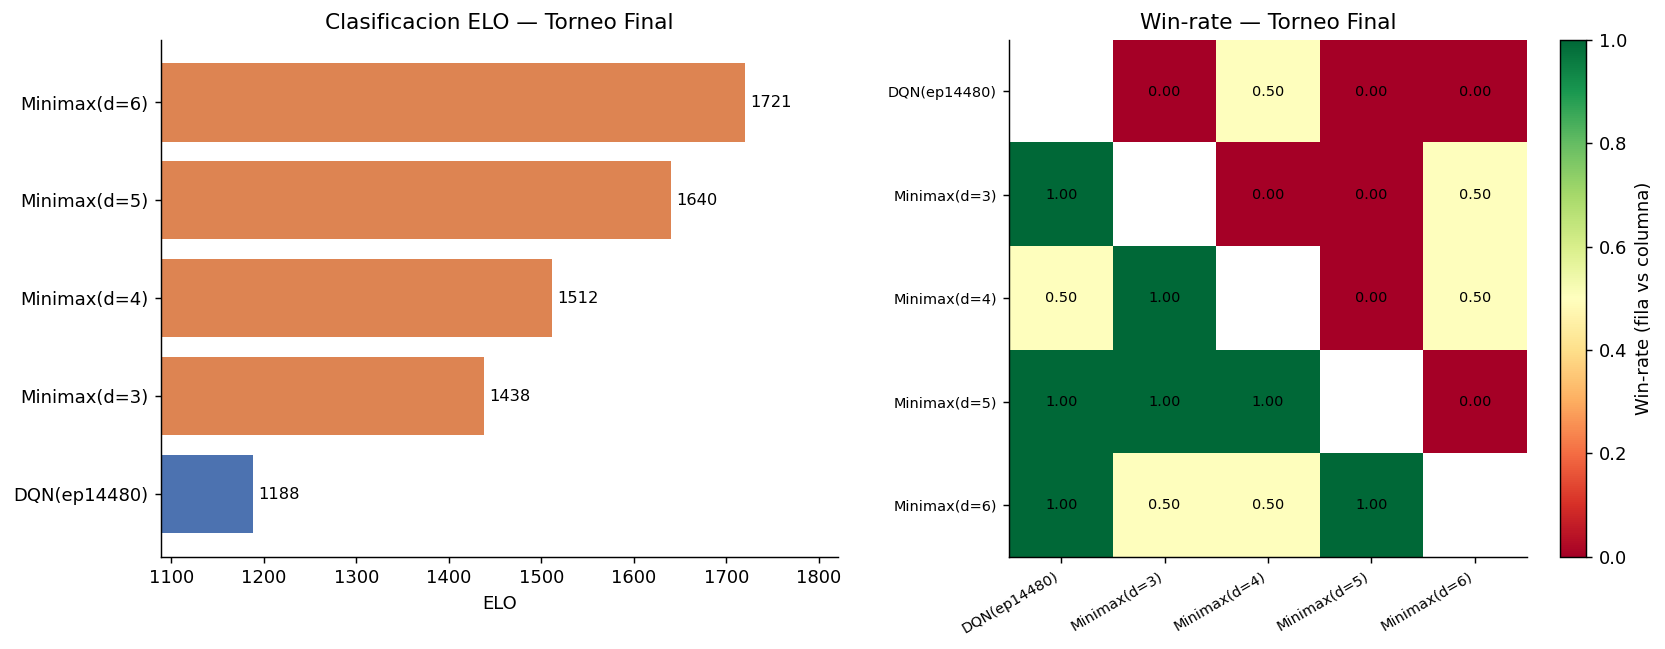

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grafico de barras ELO
ax = axes[0]
colors_elo = ['#4C72B0' if 'DQN' in a else '#DD8452' for a in df_elo['agent']]
bars = ax.barh(df_elo['agent'][::-1], df_elo['elo'][::-1], color=colors_elo[::-1])
ax.set_xlabel('ELO')
ax.set_title('Clasificacion ELO — Torneo Final')
for bar, val in zip(bars, df_elo['elo'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', fontsize=9)
ax.set_xlim(df_elo['elo'].min() - 100, df_elo['elo'].max() + 100)

# Heatmap win-rate
ax = axes[1]
agents = list(dict.fromkeys(
    df_matchups['agent_a'].tolist() + df_matchups['agent_b'].tolist()
))
n   = len(agents)
idx = {a: i for i, a in enumerate(agents)}
mat = np.full((n, n), np.nan)
for _, row in df_matchups.iterrows():
    i, j = idx[row['agent_a']], idx[row['agent_b']]
    mat[i][j] = row['win_rate_a']
    mat[j][i] = 1 - row['win_rate_a']

masked = np.ma.masked_invalid(mat)
im = ax.imshow(masked, vmin=0, vmax=1, cmap='RdYlGn')
plt.colorbar(im, ax=ax, label='Win-rate (fila vs columna)')
ax.set_xticks(range(n)); ax.set_xticklabels(agents, rotation=30, ha='right', fontsize=8)
ax.set_yticks(range(n)); ax.set_yticklabels(agents, fontsize=8)
ax.set_title('Win-rate — Torneo Final')
for i in range(n):
    for j in range(n):
        if not np.isnan(mat[i][j]):
            ax.text(j, i, f'{mat[i][j]:.2f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
savefig('torneo_final.png')
plt.show()

---
## 5. Ejemplo cualitativo: partida comentada

Se juega una partida DQN vs Minimax(d=3) y se muestran los momentos clave
(capturas y promociones) con el tablero en texto.

In [10]:
import random
from damas.engine import initial_state, legal_moves, step, is_terminal, result, _JUMP_OVER, _promotion_row
from agents.minimax import MinimaxAgent

CHECKPOINT = os.path.join(ROOT, 'models', 'checkpoint_final.pt')

_PIECE = {0: '.', 1: 'r', -1: 'b', 2: 'R', -2: 'B'}

def render(state):
    board = state['board']
    lines = ['  a b c d e f g h']
    sq = 0
    for row in range(8):
        cells = []
        for col in range(8):
            if (col % 2) == (row % 2):
                cells.append(' ')
            else:
                cells.append(_PIECE.get(board[sq], '?'))
                sq += 1
        lines.append(f'{row+1} {" ".join(cells)}')
    return '\n'.join(lines)

def is_capture(action):
    for i in range(len(action) - 1):
        if (action[i], action[i+1]) in _JUMP_OVER:
            return True
    return False

def is_promotion(action, board, turn):
    piece = board[action[0]]
    return abs(piece) == 1 and piece * turn > 0 and action[-1] in _promotion_row(turn)

if not os.path.exists(CHECKPOINT):
    print('Checkpoint no encontrado:', CHECKPOINT)
    print('Ejecuta selfplay.py para generarlo.')
else:
    from agents.dqn import DQNAgent
    dqn_agent = DQNAgent()
    dqn_agent.load(CHECKPOINT)

    minimax = MinimaxAgent(depth=3, player=1)
    state   = initial_state()
    history = []

    for hm in range(200):
        if is_terminal(state):
            break
        if state['turn'] == 1:
            action = dqn_agent.act(state, greedy=True)
            actor  = 'DQN (rojo)'
        else:
            action = minimax.choose_action(state)
            actor  = 'Minimax(d=3) (negro)'
        board_snap = list(state['board'])
        cap  = is_capture(action)
        prom = is_promotion(action, board_snap, state['turn'])
        history.append((hm+1, actor, action, cap, prom, board_snap))
        state = step(state, action)

    outcome = result(state)
    label   = {1: 'Victoria roja (DQN)', -1: 'Victoria negra (Minimax)', 0: 'Empate', None: 'Empate'}
    print(f'Resultado: {label.get(outcome)}  |  Semijugadas: {len(history)}\n')

    highlights = [(hm, actor, action, cap, prom, snap)
                  for hm, actor, action, cap, prom, snap in history
                  if cap or prom]

    print(f'Momentos destacados ({len(highlights)} capturas/promociones):')
    for hm, actor, action, cap, prom, snap in highlights[:4]:
        tipos = []
        if cap:  tipos.append('CAPTURA')
        if prom: tipos.append('PROMOCION')
        print(f'\nSemijugada {hm} — {actor}  [{", ".join(tipos)}]')
        print(f'Accion: {action}')
        tmp = {'board': snap, 'turn': 1, 'no_capture_count': 0}
        print(render(tmp))
        print()

Resultado: Victoria negra (Minimax)  |  Semijugadas: 38

Momentos destacados (13 capturas/promociones):

Semijugada 4 — Minimax(d=3) (negro)  [CAPTURA]
Accion: (19, 10, 17)
  a b c d e f g h
1   r   r   r   r
2 r   r   r   r  
3   r   .   .   r
4 .   .   r   r  
5   .   .   .   b
6 b   b   b   .  
7   b   b   b   b
8 b   b   b   b  


Semijugada 8 — Minimax(d=3) (negro)  [CAPTURA]
Accion: (20, 13)
  a b c d e f g h
1   r   r   r   r
2 r   r   r   r  
3   .   .   .   r
4 .   .   b   .  
5   r   .   .   .
6 b   b   b   .  
7   b   b   b   b
8 b   b   b   b  


Semijugada 11 — DQN (rojo)  [CAPTURA]
Accion: (15, 22)
  a b c d e f g h
1   r   r   r   r
2 r   r   r   r  
3   .   .   .   .
4 .   b   b   r  
5   .   .   b   .
6 .   b   .   .  
7   b   b   b   b
8 b   b   b   b  


Semijugada 12 — Minimax(d=3) (negro)  [CAPTURA]
Accion: (25, 18)
  a b c d e f g h
1   r   r   r   r
2 r   r   r   r  
3   .   .   .   .
4 .   b   b   .  
5   .   .   .   .
6 .   b   r   .  
7   b   b   b   b
8 b   b

---
## Resumen de figuras generadas

Todas las figuras se guardaron en `Informe/figures/` las incluiremos en eel informe:

- `curva_aprendizaje.png` — loss y epsilon durante el entrenamiento 
- `tuning_winrate.png` — comparacion de configuraciones (
- `torneo_profundidades.png` — win-rate DQN vs Minimax(d=3..6) 
- `torneo_final.png` — ELO y heatmap del torneo final 